# 估算财富税收入

## 概述

在本讲座中，我们讨论一个有助于说明最大似然方法价值的估计问题。

这个问题是：对极富有人群的财富征税会带来多少收入？

这是一个时下热门的问题。

例如，2019 年，美国参议员伊丽莎白·沃伦提出对家庭净资产超过 5000 万美元的部分每年征税，超过 10 亿美元的部分税率更高（参见 [提案](https://elizabethwarren.com/plans/ultra-millionaire-tax)）。

埃马纽埃尔·赛斯和加布里埃尔·祖克曼估计，该税收方案将在十年内带来约 2.75 万亿美元的收入（[致沃伦的信](https://www.warren.senate.gov/wp-content/uploads/media/doc/saez-zucman-wealthtax.pdf)），并在 {cite}`saez2019progressive` 中详细讨论了财富税问题。

其他经济学家认为这些估计过高，而这种分歧主要集中在最富有家庭的数量和财富上。

在本讲座中，我们使用美国家庭调查数据来估算财富税的收入。

估计工作颇具挑战性，因为最富有的家庭在数据中的代表性不足。

为了填补这一空白，我们使用帕累托分布来建模财富分布的上尾，并通过 {doc}`最大似然法 <mle_intro>` 进行拟合。

我们将使用以下导入语句。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 税收方案

我们研究对沃伦提案的一种修改版本，其边际税率表如下：

| 净资产 | 边际税率 |
|---|---|
| 1000 万美元以下 | 0% |
| 1000 万至 5000 万美元 | 1% |
| 5000 万至 10 亿美元 | 2% |
| 10 亿美元以上 | 6% |

我们可以如下表示这个税率表。

设 $h(w)$ 为净资产为 $w$ 的家庭所需缴纳的税款。

我们可以将 $h$ 写为

$$
    h(w) = \sum_{k=1}^{3} r_k \, (w - t_k)^+
$$ (eq:wt_tax)

其中

* $x^+ = \max\{x, 0\}$，
* 阈值为 $t_1 = 10\text{M}$、$t_2 = 50\text{M}$ 和 $t_3 = 1000\text{M}$，以及
* $r_1 = 0.01$，$r_2 = 0.01$，$r_3 = 0.04$

注意每个 $r_k$ 是边际税率在 $t_k$ 处的*增量*。

以下是我们在 Python 中如何表示这个函数。

In [2]:
thresholds = np.array([10e6, 50e6, 1e9])
rate_increases = np.array([0.01, 0.01, 0.04])

def h(w, thresholds=thresholds, rate_increases=rate_increases):
    "Tax paid by a household with net worth w."
    return sum(r * np.maximum(w - t, 0)
               for t, r in zip(thresholds, rate_increases))

总收入是全国所有家庭的 $h(w)$ 之和。

## 调查估计值

我们的数据来自美联储理事会运行的 2022 年 [消费者财务调查](https://www.federalreserve.gov/econres/scfindex.htm)（SCF）。

这些数据已有几年历史，但对于本练习而言已经足够。

In [3]:
url = ('https://github.com/QuantEcon/data-lectures/raw/main/'
       'lectures/us_household_net_worth_2022.csv')
scf = pd.read_csv(url)
scf.head()

,yy1,y1,wgt,networth
0,1,11,3027.956120,762100.0
1,1,12,3054.900065,854300.0
2,1,13,3163.637766,678200.0
3,1,14,3166.228463,279600.0
4,1,15,3235.624715,602600.0


每一行记录了被调查家庭的净资产 `networth` 和一个**调查权重** `wgt`。

该权重表示这一行所代表的美国家庭数量。

（这些权重用于调整财富分布不同部分的欠抽样和过抽样。）

In [4]:
w = scf['networth'].to_numpy()
λ = scf['wgt'].to_numpy()

λ.sum() / 1e6     # number of US households, in millions

np.float64(131.3063893834636)

对总收入的一个明显估计是以下加权和。

$$
\hat T_S = \sum_i \lambda_i \, h(w_i)
$$

这里 $\lambda_i$ 是第 $i$ 行的权重。

In [5]:
T_survey = np.sum(λ * h(w))
print(f"survey estimate: ${T_survey / 1e9:.0f} billion per year")

survey estimate: $533 billion per year


## 缺失的富人

由于设计原因，SCF 排除了一些极富有的美国人，因为这些人太容易被识别。

这意味着我们的估计值偏低。

让我们统计一下调查中不同财富水平以上的家庭数量。

In [6]:
levels = [10e6, 50e6, 100e6, 1e9, 2.7e9]
pd.DataFrame({
    'survey households': [scf.loc[w > c, 'yy1'].nunique() for c in levels],
    'US households represented': [round(λ[w > c].sum()) for c in levels]},
    index=['> $10M', '> $50M', '> $100M', '> $1B', '> $2.7B'])

,survey households,US households represented
> $10M,676,2132856
> $50M,311,185003
> $100M,194,64443
> $1B,21,1655
> $2.7B,0,0


调查中只有约二十个家庭财富超过 10 亿美元，而没有一个超过 27 亿美元。

27 亿美元恰好是 2022 年进入《福布斯》400 强榜单所需的财富。

这些个人合计拥有 4.0 万亿美元的财富（[《福布斯》](https://www.forbes.com/sites/chasewithorn/2022/09/27/the-2022-forbes-400-list-of-richest-americans-facts-and-figures/)）。

In [7]:
forbes_count = 400
forbes_cutoff = 2.7e9
forbes_wealth = 4.0e12

print(f"total wealth in the survey: ${np.sum(λ * w) / 1e12:.0f} trillion")

total wealth in the survey: $139 trillion


因此，在 2022 年，福布斯 400 强持有约 3% 的美国家庭财富，而这些财富全部在调查中缺失。

福布斯 400 强需要缴纳多少税？

我们只知道他们的合计财富，而不知道每个成员的财富，因此我们不能简单地对每个成员应用 $h$。

但每个成员的财富都超过 10 亿美元，而在这一水平以上，税收计算很简单：财富为 $w$ 的成员在首个 10 亿美元上缴纳 $h(1\text{B})$，超出部分按 6% 缴纳。

将所有成员加总，得到

$$
400 \cdot h(1\text{B}) + 0.06 \cdot (\text{combined wealth} - 400 \cdot 1\text{B})
$$

这只取决于他们的合计财富。

In [8]:
tax_on_first_billion = h(1e9)                # paid in full by every member
wealth_above_billion = forbes_wealth - forbes_count * 1e9
forbes_tax = forbes_count * tax_on_first_billion + 0.06 * wealth_above_billion
print(f"tax owed by the Forbes 400: ${forbes_tax / 1e9:.0f} billion per year")

tax owed by the Forbes 400: $224 billion per year


相对于调查估计值而言，这是一笔巨大的金额，而 $\hat T_S$ 完全遗漏了它。

还有第二个更为微妙的问题。

即使在调查确实包含极富有家庭的地方，其数量也非常少，因此调查对最高税档收入的估计仅依赖于少数几个观测值，具有很高的不确定性。

## 上尾的帕累托模型

为了解决这些问题，我们需要一个财富分布上尾的模型，可以从调查观测到的尾部部分进行估计，然后推广到调查未能观测到的部分。

正如 {doc}`heavy_tails` 中讨论的那样，标准模型是帕累托分布，其起源可追溯到 {cite:t}`pareto1896cours`。

这一选择有充分的经验支持 {cite}`saez2016wealth`、{cite}`vermeulen2018fat`。

同样也有理论支持：许多财富以随机速率增长的模型都会产生帕累托上尾 {cite}`gabaix2016power`、{cite}`jones2015pareto`、{cite}`benhabib2018skewed`。

回顾 {doc}`heavy_tails`，如果财富 $W$ 在某个阈值 $u$ 以上具有尾指数为 α 的帕累托尾部，那么

$$
\mathbb{P}\{W > x \mid W > u\} = \left( \frac{u}{x} \right)^\alpha
\qquad (x \geq u)
$$

取对数后，$\ln \mathbb{P}\{W > x\}$ 是 $\ln x$ 的线性函数，斜率为 $-\alpha$。

因此，当我们在对数-对数坐标轴上绘制互补累积分布函数（超过 $x$ 的概率）与 $x$ 的关系图时，帕累托尾部会表现为一条直线。

让我们绘制调查数据的互补累积分布函数，使用权重使每一行按其所代表的家庭数量成比例计入。

In [9]:
def weighted_ccdf(x_grid, w, λ):
    "Fraction of households with wealth above each point of x_grid."
    return np.array([λ[w > x].sum() for x in x_grid]) / λ.sum()

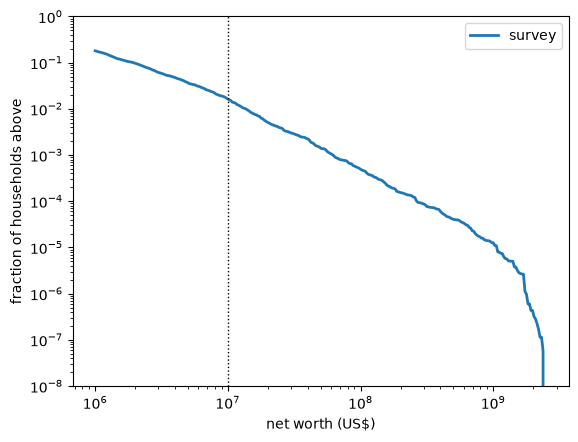

In [10]:
x_grid = np.geomspace(1e6, 2.5e9, 300)

fig, ax = plt.subplots()
ax.loglog(x_grid, weighted_ccdf(x_grid, w, λ), lw=2, label='survey')
ax.axvline(10e6, color='k', ls=':', lw=1)
ax.set_ylim(1e-8, 1)
ax.set_xlabel('net worth (US$)')
ax.set_ylabel('fraction of households above')
ax.legend()
plt.show()

在约 1000 万美元以下（虚线处），曲线发生弯折，因此该区域的分布不是帕累托分布。

在 1000 万美元以上，曲线接近一条直线。

在最右端，曲线急剧下降，因为调查数据止于略低于 24 亿美元处。

因此，我们在阈值 $u = 1000$ 万美元以上拟合帕累托尾部，这也正是我们税收方案的起始点。

## 估计尾指数

在 {doc}`mle_intro` 中，我们发现，给定已知阈值 $u$ 以上的观测值 $x_1, \ldots, x_n$，尾指数的最大似然估计为

$$
\hat \alpha = \frac{n}{\sum_{i=1}^n \ln (x_i / u)}
$$

这里我们必须考虑权重。

如果第 $i$ 行代表 $\lambda_i$ 个家庭，那么它对总体对数似然的贡献是其对数密度的 $\lambda_i$ 份拷贝：

$$
\ell(\alpha) = \sum_{i: w_i > u} \lambda_i \ln f(w_i; \alpha)
$$

用这些权重重复 {doc}`mle_intro` 中的计算，得到

$$
\hat \alpha = \frac{\sum_{i: w_i > u} \lambda_i}
                  {\sum_{i: w_i > u} \lambda_i \ln (w_i / u)}
$$

In [11]:
def tail_index(u, w, λ):
    "Weighted maximum likelihood estimate of the Pareto tail index above u."
    above = w > u
    return λ[above].sum() / np.sum(λ[above] * np.log(w[above] / u))

u = 10e6
α_hat = tail_index(u, w, λ)
α_hat

np.float64(1.5624405884551842)

这与已发表的美国估计值相近，后者约为 1.5 {cite}`vermeulen2018fat`。

## 收入的帕累托估计

在估计出尾部后，我们可以根据模型而非调查来计算收入。

设 $N_u$ 为财富超过 $u$ 的家庭数量，我们根据调查权重来估计它。

In [12]:
N_u = λ[w > u].sum()
N_u

np.float64(2132856.3510950943)

收入等于 $N_u$ 乘以财富超过 $u$ 的家庭的平均纳税额。

利用 {eq}`eq:wt_tax`，这个平均值为

$$
\mathbb{E}[h(W) \mid W > u] = \sum_{k} r_k \, \mathbb{E}[(W - t_k)^+ \mid W > u]
$$

对于阈值 $u$ 以上的帕累托尾部和阈值 $t \geq u$，一个简短的计算表明

$$
\mathbb{E}[(W - t)^+ \mid W > u]
= \int_t^\infty (x - t) \, \frac{\alpha u^\alpha}{x^{\alpha + 1}} \, dx
= \frac{u^\alpha t^{1 - \alpha}}{\alpha - 1}
$$ (eq:wt_excess)

前提是 α > 1。

（当 α ≤ 1 时，积分为无穷大，因此预期税额也是无穷大。）

综合这些结果，得到收入的帕累托估计：

$$
\hat T_P = N_u \sum_k r_k \frac{u^{\hat \alpha} t_k^{1 - \hat \alpha}}{\hat \alpha - 1}
$$

In [13]:
def expected_excess(t, α, u):
    "Expected value of (W - t)^+ for a Pareto tail above u, with t >= u."
    return u**α * t**(1 - α) / (α - 1)

def pareto_revenue(α, u, N_u,
                   thresholds=thresholds, rate_increases=rate_increases):
    "Pareto estimate of revenue, for a tail above u containing N_u households."
    return N_u * np.sum(rate_increases * expected_excess(thresholds, α, u))

T_pareto = pareto_revenue(α_hat, u, N_u)
print(f"Pareto estimate: ${T_pareto / 1e9:.0f} billion per year")

Pareto estimate: $646 billion per year


## 比较两种估计值

帕累托估计值高于调查估计值。

为了看出差异的来源，让我们按税档分解收入。

第 $k$ 档的收入是财富在 $t_k$ 和 $t_{k+1}$ 之间的部分按该档边际税率计算的税额。

In [14]:
marginal_rates = np.cumsum(rate_increases)
upper = np.append(thresholds[1:], np.inf)

survey_by_bracket = [np.sum(λ * m * np.clip(np.minimum(w, t_up) - t, 0, None))
                     for t, t_up, m in zip(thresholds, upper, marginal_rates)]

def excess_between(t, t_up, α, u):
    "Expected wealth between t and t_up, for a Pareto tail above u."
    top = expected_excess(t_up, α, u) if np.isfinite(t_up) else 0.0
    return expected_excess(t, α, u) - top

pareto_by_bracket = [N_u * m * excess_between(t, t_up, α_hat, u)
                     for t, t_up, m in zip(thresholds, upper, marginal_rates)]

table = pd.DataFrame({'survey': survey_by_bracket,
                      'Pareto': pareto_by_bracket},
                     index=['$10M-$50M at 1%', '$50M-$1B at 2%', 'above $1B at 6%'])
table.loc['total'] = table.sum()
(table / 1e9).round(0)     # billions of dollars per year

,survey,Pareto
$10M-$50M at 1%,227.0,226.0
$50M-$1B at 2%,273.0,250.0
above $1B at 6%,32.0,171.0
total,533.0,646.0


在第一档中，调查拥有数百个家庭观测值，两种估计几乎完全一致。

这令人放心，因为它表明帕累托模型很好地描述了调查所观测到的那部分尾部。

随着我们向上移动，估计值出现分歧，而在最高税档中，帕累托估计值要大出好几倍。

这正是调查数据稀疏并随后终止的地方，也正是我们对缺失家庭产生担忧的地方。

## 与福布斯 400 强的对照检验

帕累托模型对不在调查中的家庭做出了预测，我们可以用福布斯 400 强来检验这些预测。

根据该模型，财富超过福布斯门槛 $c = 27$ 亿美元的家庭数量为 $N_u (u / c)^{\alpha}$。

这些家庭的平均财富为 $\alpha c / (\alpha - 1)$，这可由 {eq}`eq:wt_excess` 令 $u = t = c$ 并加上 $c$ 得出。

In [15]:
n_forbes_model = N_u * (u / forbes_cutoff)**α_hat
wealth_forbes_model = n_forbes_model * α_hat * forbes_cutoff / (α_hat - 1)

pd.DataFrame({'Pareto model': [n_forbes_model, wealth_forbes_model / 1e12],
              'Forbes': [forbes_count, forbes_wealth / 1e12]},
             index=['households above $2.7B', 'their wealth ($ trillion)']).round(1)

,Pareto model,Forbes
households above $2.7B,338.9,400.0
their wealth ($ trillion),2.5,4.0


该模型在这一水平预测的家庭数量比福布斯统计的略少，财富总额也明显偏低，但在数量级上是正确的。

这是一项严格的检验，因为该模型完全是根据财富低于 24 亿美元的调查家庭估计出来的。

我们可以通过将拟合的帕累托直线延伸到调查数据之外，并将福布斯 400 强作为单个数据点添加进去，从图形上看出这一点。

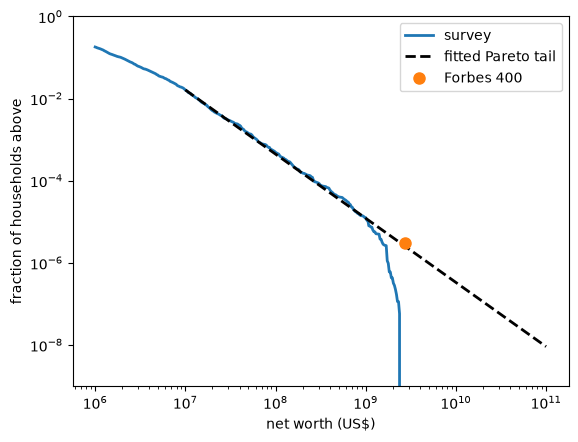

In [16]:
N = λ.sum()
x_fit = np.geomspace(u, 1e11, 100)

fig, ax = plt.subplots()
ax.loglog(x_grid, weighted_ccdf(x_grid, w, λ), lw=2, label='survey')
ax.loglog(x_fit, (N_u / N) * (u / x_fit)**α_hat, 'k--', lw=2,
          label='fitted Pareto tail')
ax.loglog(forbes_cutoff, forbes_count / N, 'o', ms=8, label='Forbes 400')
ax.set_ylim(1e-9, 1)
ax.set_xlabel('net worth (US$)')
ax.set_ylabel('fraction of households above')
ax.legend()
plt.show()

福布斯数据点位于拟合直线稍微上方。

原因可能有几种。

* α 的估计值存在不确定性，一个稍小的值将会通过福布斯数据点。
* 分布的最顶端可能比我们用来估计 α 的范围具有更重的尾部。
* 富裕家庭可能不太愿意回应调查，这会使 α 的估计值偏高 {cite}`vermeulen2018fat`。
* 《福布斯》使用自己的估值方法统计个人和家族，这与调查中对家庭净资产的定义有所不同。

这一比较表明，如果说存在偏差的话，我们对收入的帕累托估计反而是保守的。

## α 有多重要？

$\hat T_P$ 的公式中，分母包含 $\hat \alpha - 1$ 这一项。

因此，随着 α 趋近于 1，估计收入将无限增大。

让我们绘制收入与 α 的关系图。

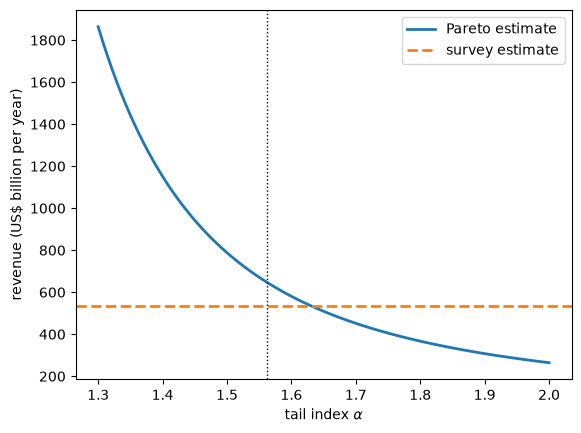

In [17]:
α_values = np.linspace(1.3, 2.0, 100)
revenue = [pareto_revenue(a, u, N_u) for a in α_values]

fig, ax = plt.subplots()
ax.plot(α_values, np.array(revenue) / 1e9, lw=2, label='Pareto estimate')
ax.axhline(T_survey / 1e9, color='C1', ls='--', lw=2, label='survey estimate')
ax.axvline(α_hat, color='k', ls=':', lw=1)
ax.set_xlabel(r'tail index $\alpha$')
ax.set_ylabel('revenue (US$ billion per year)')
ax.legend()
plt.show()

将 α 从 1.6 移动到 1.4——这一变化完全处于抽样不确定性的范围之内（参见 {ref}`本练习 <wt_ex_bootstrap>`）——估计收入大约翻了一倍。

这种敏感性是财富税收入估计如此存在争议的原因之一。

最后，我们所有的估计都是*机械式*的：它们假设家庭不会因税收而改变其行为。

实际上，富裕家庭可能通过转移资产、改变资产估值方式或以其他方式规避税收来做出反应，而这些反应的大小正是政策辩论中的核心问题 {cite}`saez2019progressive`。

## 练习

```{exercise-start}
:label: wt_ex_warren
```

沃伦最初的提案对净资产超过 5000 万美元的部分征收 2% 的税，对超过 10 亿美元的部分征收 3% 的税。

计算该税率表下收入的调查估计值和帕累托估计值。

将它们与赛斯和祖克曼估计的每年约 2750 亿美元（十年内 2.75 万亿美元）进行比较。

```{exercise-end}
```

```{solution-start} wt_ex_warren
:class: dropdown
```

我们将新的阈值和税率增量传递给我们的函数。

In [18]:
warren = dict(thresholds=np.array([50e6, 1e9]),
              rate_increases=np.array([0.02, 0.01]))

T_s = np.sum(λ * h(w, **warren))
T_p = pareto_revenue(α_hat, u, N_u, **warren)
print(f"survey estimate: ${T_s / 1e9:.0f} billion per year")
print(f"Pareto estimate: ${T_p / 1e9:.0f} billion per year")

survey estimate: $289 billion per year
Pareto estimate: $335 billion per year


两种估计值都与赛斯和祖克曼的数字处于同一数量级。

他们的估计在几个方面与我们的不同：涵盖 2019 年至 2028 年，对分布顶端使用了不同的数据，并包含了税收规避的调整空间。

因此这种比较只是粗略的。

```{solution-end}
```

```{exercise-start}
:label: wt_ex_bootstrap
```

估计值 $\hat \alpha$ 存在抽样波动。

衡量这一点的一种方法是**自助法（bootstrap）**：从调查家庭中有放回地抽取一个新样本，重新计算估计值，并重复多次。

由于每个家庭出现在五行数据中，请对家庭（由 `yy1` 标识）而非对行进行重新抽样。

使用 200 个自助样本，计算 $u = 1000$ 万美元处 $\hat \alpha$ 的 90% 区间，以及相应的 $\hat T_P$ 区间。

```{exercise-end}
```

```{solution-start} wt_ex_bootstrap
:class: dropdown
```

In [19]:
rng = np.random.default_rng(1234)
rows_by_household = scf.groupby('yy1').indices
households = np.array(list(rows_by_household.keys()))

α_boot, T_boot = [], []
for _ in range(200):
    draw = rng.choice(households, size=len(households))
    idx = np.concatenate([rows_by_household[hh] for hh in draw])
    w_b, λ_b = w[idx], λ[idx]
    a = tail_index(u, w_b, λ_b)
    α_boot.append(a)
    T_boot.append(pareto_revenue(a, u, λ_b[w_b > u].sum()))

print("90% interval for α:", np.percentile(α_boot, [5, 95]).round(2))
print("90% interval for revenue ($ billion):",
      (np.percentile(T_boot, [5, 95]) / 1e9).round(0))

90% interval for α: [1.43 1.71]
90% interval for revenue ($ billion): [481. 964.]


α 的区间大致在估计值周围 ±0.15 的范围内。

收入的区间很宽，这反映了前面讨论的对 α 的敏感性。

```{solution-end}
```

```{exercise-start}
:label: wt_ex_hybrid
```

在第一档中，调查估计值与帕累托估计值一致，因为调查在该档拥有大量观测值。

这提示我们可以采用一种**混合**估计：对财富低于 5000 万美元的家庭使用调查数据，对其余家庭使用帕累托模型（仍然在 $u = 1000$ 万美元以上拟合）。

计算这个估计值。

提示：财富为 $W > c = 5000$ 万美元的家庭在第一档缴纳
$0.01 (c - 10\text{ million})$，再加上
$0.02 (W - c) + 0.04 (W - 1 \text{ billion})^+$。

```{exercise-end}
```

```{solution-start} wt_ex_hybrid
:class: dropdown
```

在帕累托尾部上对提示中的公式取平均，并乘以家庭数量，超过 $c$ 的家庭所贡献的收入为

$$
N_c \cdot 0.01 (c - 10\text{ million})
+ N_u \left( 0.02 \, \mathbb{E}[(W - c)^+ \mid W > u]
            + 0.04 \, \mathbb{E}[(W - 1\text{ billion})^+ \mid W > u] \right)
$$

其中 $N_c = N_u (u / c)^\alpha$ 是财富超过 $c$ 的家庭数量。

In [20]:
c = 50e6
below = w <= c
T_below = np.sum(λ[below] * h(w[below]))

N_c = N_u * (u / c)**α_hat
T_above = (N_c * 0.01 * (c - 10e6)
           + N_u * (0.02 * expected_excess(c, α_hat, u)
                    + 0.04 * expected_excess(1e9, α_hat, u)))

print(f"hybrid estimate: ${(T_below + T_above) / 1e9:.0f} billion per year")

hybrid estimate: $643 billion per year


混合估计值介于调查估计值和帕累托估计值之间，并且接近帕累托估计值，因为这两者之间的大部分差异来自最高的几个税档。

```{solution-end}
```